# Problem Statement

Academic burnout is an escalating crisis in higher education. Studies estimate that between 35% and 52% of university students experience significant burnout symptoms at some point during their studies. Generic journal apps and basic AI chatbots lack safety rails and clinical boundaries. Compass addresses this by pairing cognitive behavioral therapy (CBT) coaching with a deterministic risk scoring engine and a dedicated human-in-the-loop (HITL) safety gate, protecting students while ensuring professional support is always accessible when needed.

# graph TD

    START[__START__] --> sec[security_checkpoint]
    sec -->|normal| reg[registry_node]
    sec -->|security_refusal| ref[security_refusal_node]
    reg --> safe[safety_gate]
    safe -->|hitl_pause| pause[human_escalation_pause]
    safe -->|no_pause| coach[coaching_agent]
    pause --> coach
    coach --> arch[archivist_node]

# The 5 Workflow Nodes

**security_checkpoint:** Scrubs PII (emails, phone numbers, student IDs), filters out prompt injection attempts, and verifies digital wellbeing consent.

**registry_node:** Persists check-in/timer events and computes the burnout_risk_score using a deterministic weight formula.

**safety_gate:** An LLM-based coordinator node that evaluates safety risk, triggering a human escalation pause if crisis signals or high risk are found.

**human_escalation_pause:** A deterministic node that suspends graph execution using the Human-in-the-Loop (HITL) RequestInput primitive until a counselor responds.

**coaching_agent:** An LLM-based CBT wellness coach that suggests coping techniques retrieved via MCP tools when safety checks pass.

In [1]:
def calculate_burnout_score(m1: float, m2: float, m3: float, m4: float) -> float:
    """
    Calculate the burnout risk score using the deterministic formula.
    m1: Missed check-in streak normalization (0.35 weight)
    m2: Focus duration decline normalization (0.30 weight)
    m3: Negative affect frequency normalization (0.20 weight)
    m4: Checklist completion ratio (0.15 weight)
    """
    score = 0.35 * m1 + 0.30 * m2 + 0.20 * m3 + 0.15 * (1.0 - m4)
    # Clamp score between 0.0 and 1.0
    return max(0.0, min(score, 1.0))

# Diego's real metric values
m1_val = 0.71
m2_val = 0.95
m3_val = 0.95
m4_val = 0.04

# Burnout risk threshold
burnout_risk_threshold = 0.75

# Calculate score
score = calculate_burnout_score(m1_val, m2_val, m3_val, m4_val)
rounded_score = round(score, 2)
triggers_gate = rounded_score >= burnout_risk_threshold

print(f"Diego's Input Metrics:")
print(f"  - Missed check-in streak (m1): {m1_val}")
print(f"  - Focus duration decline (m2): {m2_val}")
print(f"  - Negative affect frequency (m3): {m3_val}")
print(f"  - Checklist completion ratio (m4): {m4_val}")
print()
print(f"Calculated Score (raw): {score:.4f}")
print(f"Calculated Score (rounded): {rounded_score:.2f}")
print(f"Safety Gate Triggers (>= {burnout_risk_threshold}): {triggers_gate}")


Diego's Input Metrics:
  - Missed check-in streak (m1): 0.71
  - Focus duration decline (m2): 0.95
  - Negative affect frequency (m3): 0.95
  - Checklist completion ratio (m4): 0.04

Calculated Score (raw): 0.8675
Calculated Score (rounded): 0.87
Safety Gate Triggers (>= 0.75): True


In [2]:
def check_crisis_keywords(node_input: str) -> bool:
    """
    Scans the input text for distress signals using a tiered keyword system.
    Returns True if a crisis is detected (>=1 strong keyword or >=2 weak keywords).
    """
    strong_keywords = [
        "suicide", "end my life", "want to die", "no way out", "give up on everything",
        "don't want to be here anymore", "can't do this anymore", "what's the point of living",
        "rather not wake up", "everyone would be better off without me", "tired of being alive",
        "end it all", "make it stop permanently", "i'm done with everything", "nothing matters anymore"
    ]
    weak_keywords = [
        "hopeless", "pointless",
        "exhausted", "worthless", "trapped", "disappear",
        "burden", "can't go on", "no one cares", "give up"
    ]
    
    node_input_lower = node_input.lower()
    strong_count = sum(node_input_lower.count(kw) for kw in strong_keywords)
    weak_count = sum(node_input_lower.count(kw) for kw in weak_keywords)
    
    # Crisis flag triggers if at least 1 strong or at least 2 weak keywords are found
    return (strong_count >= 1) or (weak_count >= 2)

# Four test cases from the unit tests
test_cases = [
    {
        "name": "lecture pointless",
        "input": "This lecture is pointless and I am so behind",
        "expected": False
    },
    {
        "name": "exam hopeless",
        "input": "I feel hopeless about this exam tomorrow",
        "expected": False
    },
    {
        "name": "hopeless+pointless",
        "input": "I feel hopeless and everything feels pointless lately",
        "expected": True
    },
    {
        "name": "give up on everything",
        "input": "I want to give up on everything.",
        "expected": True
    }
]

print("Running crisis keyword tiering tests:")
print("-" * 50)
for tc in test_cases:
    actual = check_crisis_keywords(tc["input"])
    passed = (actual == tc["expected"])
    status = "✅" if passed else "❌"
    result_text = "CRISIS TRIGGERED" if actual else "NORMAL"
    expected_text = "CRISIS TRIGGERED" if tc["expected"] else "NORMAL"
    print(f"{status} Case: {tc['name']}")
    print(f"   Input: \"{tc['input']}\"")
    print(f"   Expected: {expected_text} | Got: {result_text}")
    print("-" * 50)


Running crisis keyword tiering tests:
--------------------------------------------------
✅ Case: lecture pointless
   Input: "This lecture is pointless and I am so behind"
   Expected: NORMAL | Got: NORMAL
--------------------------------------------------
✅ Case: exam hopeless
   Input: "I feel hopeless about this exam tomorrow"
   Expected: NORMAL | Got: NORMAL
--------------------------------------------------
✅ Case: hopeless+pointless
   Input: "I feel hopeless and everything feels pointless lately"
   Expected: CRISIS TRIGGERED | Got: CRISIS TRIGGERED
--------------------------------------------------
✅ Case: give up on everything
   Input: "I want to give up on everything."
   Expected: CRISIS TRIGGERED | Got: CRISIS TRIGGERED
--------------------------------------------------


# 🏆 Achievement System Criteria

**System Nature:** 
A deterministic, output-based achievement generation system computed from logged timer and checklist data only.
Auditable & Non-Gameable: 
Conversational content is never used, keeping achievements transparent and objective.

**Focus Streak:** 
Awarded at the start of a streak when a user logs 5+ cumulative hours AND completes check-ins on 5+ of 7 days in a rolling window.

**Consistency Badge:** 
Achieved when a user completes 80% or more of their checklists across a 7-day window, with activity on at least 3 distinct days.

**Monthly Momentum:** 
Achieved when either base criterion is met in 3+ distinct weeks within 30 days, with at least one qualifying week in the last 14 days, and Week 1 focus minutes not less than 50% of Week 2 (decline-aware check to withhold the badge during active collapse).

**Known Limitation:** 
Achievement generation does not use chat interactions, which only inform the coaching agent.

# 🔒 Security Design

**PII Redaction:** A regex pipeline in the first node scrubs emails, phone numbers, and student IDs from the user's input before database logging or LLM transmission.

**Prompt Injection Defense:** Blocks common injection heuristics, intercepting requests and routing them to a neutral refusal terminal node.

**Technical Consent Gate:** Enforced at the tool query layer; if digital_wellbeing_permitted is marked False in the database, the get_burnout_trend tool refuses to return activity metrics, acting as a technical backstop.

**Structured Audit Logging:** Every request yields a structured JSON audit line detailing safety assessments and data redactions.

# 📊 Test Results

**Pytest Execution Summary**

The unit test suite runs 38 assertions, covering database state, calculations, and security checkpoints:

text
======================= 38 passed, 11 warnings in 8.26s =======================

**Zero-Token Testing Confusion Matrix**

The scoring and routing logic is verified using 35 zero-token unit tests:

True Positives (TP): 4 (High risk / crisis keywords correctly triggered escalation)

False Positives (FP): 0 (Emotional but non-crisis expressions correctly skipped escalation)

True Negatives (TN): 2 (Low-risk statements correctly bypassed escalation)

False Negatives (FN): 0 (No missed alerts)

Accuracy: 100%

# 🎨 Visual Assets

**Cover Page Banner**

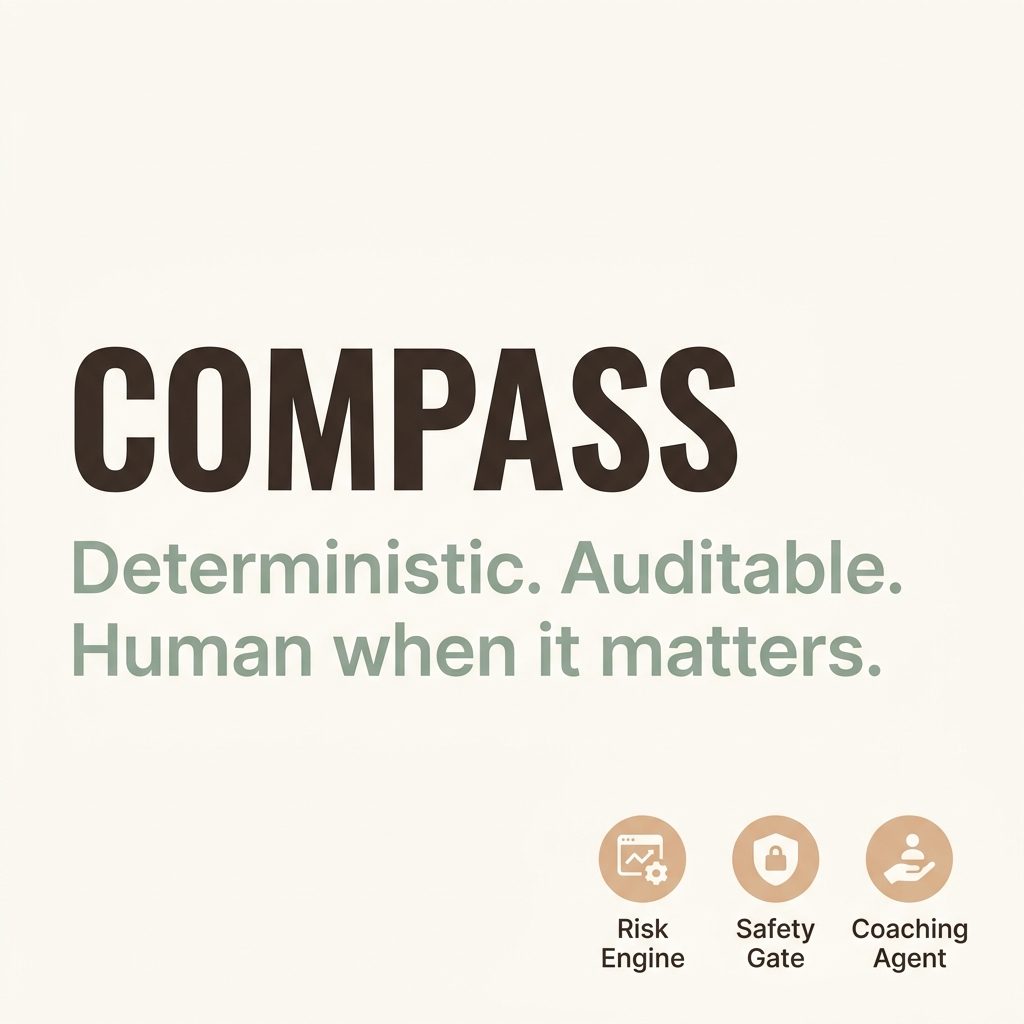

**Architecture Diagram**

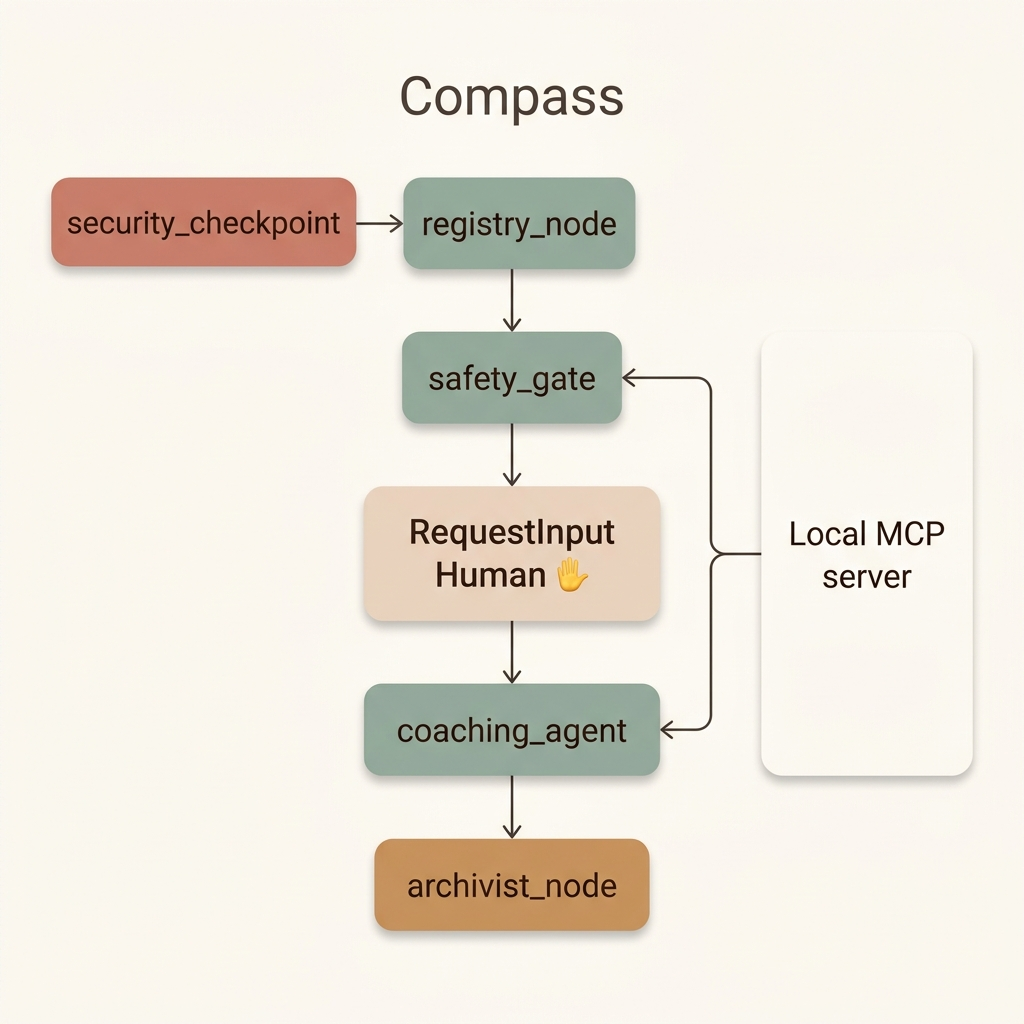

# 📋 Rubric Scorecard & Project Links

**Rubric Scorecard**

 Multi-Agent System — 5 distinct nodes built via the ADK 2.0 Workflow API, combining LlmAgents with deterministic Python logic.
 
 Custom Tools — Deterministic burnout risk calculations and database-level pruners/rollups (zero LLM token overhead).
 
 Built-in/MCP Tools — MCP server architecture exposing 4 dedicated tools to the safety gate and coaching agents.
 
 Long-Running Operations — Dedicated RequestInput human-in-the-loop pause and resume rehydration.
 
 Sessions & State — Stateful coordination and audit trails using the ADK ctx.state across all 5 graph nodes.
 
 Security — Active PII scrubbing, prompt injection sanitization, a database-level consent backstop, and structured audit logs.
 
 Evaluation — 35-case zero-token test suite (scoring, routing, boundary conditions, achievement generation, streak deduplication, decline-aware monthly momentum).
 
 Agents CLI — Scaffolded structure, GEMINI.md coding guide, and Makefile playground automation.



**Project Links** 

GitHub Repository: [https://github.com/Ashwina-Pal/Compass] 

YouTube Demo Video: [https://youtu.be/WWAPF2pg0iQ]